## 1) Import packages 

In [1]:
import pandas as pd
import re
import numpy as np
import glob
import os
from collections import defaultdict
import time
from datetime import datetime
from sklearn.metrics import jaccard_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import pickle

## 2) Load datasets 

In [2]:
# Path to the output files 
base_output_path = "/home/fab25/NPOmix_python"
output_path = os.path.join(base_output_path, "saved_files")

# # Save to file
# with open(os.path.join(output_path, 'mf_dict.pkl'), 'wb') as f:
#     pickle.dump(mf_dict, f)

# Load from file
with open(os.path.join(output_path, 'mf_dict.pkl'), 'rb') as f:
    mf_dict = pickle.load(f)

In [3]:
# Save and load the pre-testing DataFrame
# # Save the DataFrame to a pickle file
# pre_testing_df.to_pickle(os.path.join(output_path, 'pre_testing_df.pkl'))

# Load the DataFrame from the pickle file
pre_testing_df = pd.read_pickle(os.path.join(output_path, 'pre_testing_df.pkl'))
pre_testing_df.head()

,Blongum44Bv1.3.mzXML,Bact_sp_9_1_42FAA_V2.3.mzXML,SspSR1v1.2.mzXML,Clos_orbi_1_3_50AFAA_V1.3.mzXML,Clos_clos_2_1_49FAA_V1.3.mzXML,SspCM7v1.2.mzXML,Bact_vulg_CL09T03C04_V1.3.mzXML,SspCM6v1.2.mzXML,Bact_cacc_CL03T12C61_V1.3.mzXML,SspOBRC6v1.2.mzXML,...,GCA_012367695.4.mzXML,GCA_000377145.7.mzXML,2517434008.3.mzXML,GCA_000020025.18.mzXML,GCA_000020025.16.mzXML,GCA_000020025.14.mzXML,GCA_000020025.10.mzXML,GCA_000020025.5.mzXML,GCA_000020025.8.mzXML,GCA_000020025.12.mzXML
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# # Save the training_df and bgcs_df to files for later use as pickle files
# training_df.to_pickle(os.path.join(output_path, 'training_df.pkl'))
# bgcs_df.to_pickle(os.path.join(output_path, 'bgcs_df.pkl'))

# Load the training DataFrame and BGCs from pickle files if needed
training_df = pd.read_pickle(os.path.join(output_path, 'training_df.pkl'))
print(f"Shape of training_df: {training_df.shape}")
training_df.head()


Shape of training_df: (3502, 981)


,2515154094,2515154124,2515154177,2515154206,2516143022,2516493032,2517287023,2517434008,2517572157,2517572165,...,SspCM7v1,SspOBRC6v1,SspSR1v1,Stre_inte_F0413_V1,Stre_para_CC87K_V1,Stre_sang_CC94A_V1,Trep_dent_ASLM_V1,Trep_dent_US-Trep_V1,VspACP1v1,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF2


In [5]:
# # Save the testing_df to a pickle file for later use
# testing_df.to_pickle(os.path.join(output_path, 'testing_df.pkl'))

# Load the testing_df from the pickle file
testing_df = pd.read_pickle(os.path.join(output_path, 'testing_df.pkl'))
print(f"Shape of testing_df: {testing_df.shape}")
testing_df.head()

Shape of testing_df: (11186, 980)


,2515154094,2515154124,2515154177,2515154206,2516143022,2516493032,2517287023,2517434008,2517572157,2517572165,...,SspCM6v1,SspCM7v1,SspOBRC6v1,SspSR1v1,Stre_inte_F0413_V1,Stre_para_CC87K_V1,Stre_sang_CC94A_V1,Trep_dent_ASLM_V1,Trep_dent_US-Trep_V1,VspACP1v1
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# # Save the final_df to a pickle file for later use
# final_df.to_pickle(os.path.join(output_path, 'final_df.pkl'))

# Load the final_df from the pickle file
final_df = pd.read_pickle(os.path.join(output_path, 'final_df.pkl'))

#### EDA

In [7]:
# Count the nubmer of classes in the training set
print(f"Number of classes in the training set: {training_df['label'].nunique()}")

# Showing the size of smallest and largest classes along with the name of class
print(f"Size of smallest class: {training_df['label'].value_counts().min()}") 
print(f"Size of largest class: {training_df['label'].value_counts().max()}")



Number of classes in the training set: 657
Size of smallest class: 1
Size of largest class: 83


In [8]:
class_counts = training_df['label'].value_counts()
count_counts = class_counts.value_counts()

# sort the counts in descending order
count_counts = count_counts.sort_values(ascending=False)

print(count_counts)

count
2     311
3      92
4      55
5      43
6      23
9      17
12     16
7      13
10     12
8      10
13      9
11      8
1       6
14      4
19      4
31      3
21      3
15      3
24      2
38      2
27      2
17      2
23      2
20      2
18      2
16      1
76      1
22      1
25      1
28      1
39      1
49      1
54      1
62      1
63      1
83      1
Name: count, dtype: int64


In [9]:
# Get the summation of index * value in count_counts
np.sum(count_counts.index * count_counts)

3502

In [10]:
np.sum(count_counts)

657

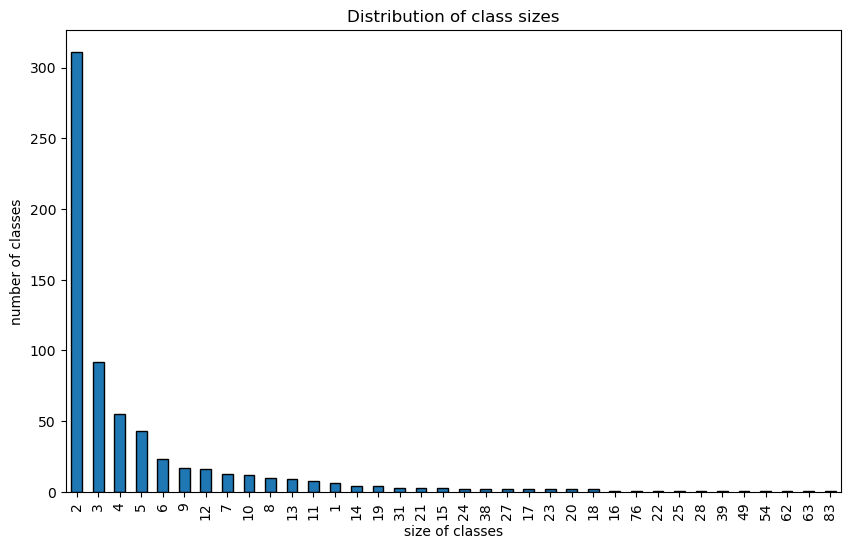

In [13]:
plt.figure(figsize=(10, 6))
count_counts.plot(kind='bar', edgecolor='black')
plt.xlabel('size of classes')
plt.ylabel('number of classes')
plt.title('Distribution of class sizes')
plt.show()

In [39]:
# Create a new training set taking only two samples from each class
# (if class has less than 2 samples, remove it; if it has 2, keep both; if more, sample 2 randomly)
new_training_df = (
    training_df.groupby('label')
    .filter(lambda x: len(x) >= 2)           # Keep only classes with at least 2 samples
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(2, random_state=42))  # Take 2 samples per class
    .reset_index(drop=True)
)

/tmp/ipykernel_2256250/1492976849.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(2, random_state=42))  # Take 2 samples per class


In [41]:
new_training_df.head()

,2515154094,2515154124,2515154177,2515154206,2516143022,2516493032,2517287023,2517434008,2517572157,2517572165,...,SspCM7v1,SspOBRC6v1,SspSR1v1,Stre_inte_F0413_V1,Stre_para_CC87K_V1,Stre_sang_CC94A_V1,Trep_dent_ASLM_V1,Trep_dent_US-Trep_V1,VspACP1v1,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF10
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF10
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF100


## 3) ML model 

In [54]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
# 1. Load data
# Use the new balanced training set
X_train = new_training_df.drop(columns=['label'])
y_train = new_training_df['label']

# Test set
X_test = testing_df.copy()

# Ensure all column names are Python strings
X_train.columns = [str(col) for col in X_train.columns]
X_test.columns = [str(col) for col in X_test.columns]

In [ ]:
# Encode labels 
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

In [56]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_encoded)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [57]:
# Predict Top-3 Classes for Each Test Sample

import numpy as np
import pandas as pd

probs = clf.predict_proba(X_test)
top3_indices = np.argsort(probs, axis=1)[:, -3:][:, ::-1]  # Top 3, descending order
top3_labels = label_encoder.inverse_transform(top3_indices.ravel()).reshape(top3_indices.shape)

# Create output DataFrame
top3_df = pd.DataFrame(top3_labels, columns=['top1', 'top2', 'top3'])
top3_df.index = X_test.index  # Retain original index if needed

### Evaluation 

In [58]:
top3_df

,top1,top2,top3
5668,GCF460,GCF473,GCF374
7209,GCF94,GCF192,GCF486
10731,GCF460,GCF473,GCF374
10763,GCF81,GCF82,GCF80
11459,GCF486,GCF366,GCF154
...,...,...,...
2710434,GCF2,GCF3,GCF5
2710471,GCF580,GCF587,GCF589
2710780,GCF5,GCF3,GCF2
2710856,GCF361,GCF484,GCF364


In [60]:
# Load the annotated_nodes_df
output_path = '/home/fab25/NPOmix_python/saved_files'
annotated_nodes_df = pd.read_pickle(os.path.join(output_path, 'annotated_nodes_df.pkl'))
annotated_nodes_df.head()

,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name,predicted_GCF
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557,NaN,NaN,"[GCF460, GCF473, GCF72]"
171,7209,Benzoic acid,CCMSLIB00006359930,NaN,NaN,"[GCF192, GCF192, GCF192]"
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055,NaN,NaN,"[GCF460, GCF473, GCF72]"
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430,NaN,NaN,NaN
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912,NaN,NaN,"[GCF81, GCF81, GCF81]"


In [68]:
# load bigscape_dict2.pkl
with open(os.path.join(output_path, 'bigscape_dict2.pkl'), 'rb') as f:
    bigscape_dict2 = pickle.load(f)

# Show first three samples
list(bigscape_dict2.items())[:3]

[('GCF1',
  ['GCA_002994615.region022',
   'GCA_000737335.region031',
   'GCA_000170895.region002',
   'GCA_002994635.region018']),
 ('GCF2',
  [np.str_('BGC0000845.1'),
   'DS570624.region002',
   np.str_('BGC0000844.1'),
   np.str_('BGC0000319.1')]),
 ('GCF3', ['DS570624.region019', np.str_('BGC0000373.1')])]

In [69]:
# Just keep those rows which are not nan in BGC_accessions predicted_GCF columns (in both columns)
merged = annotated_nodes_df[annotated_nodes_df['BGC_accessions'].notna() & annotated_nodes_df['predicted_GCF'].notna()]

# Display the first few rows of the annotated nodes DataFrame
merged

,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name,predicted_GCF
7025,110408,Clavulanic acid,CCMSLIB00005435929,"['BGC0000841', 'BGC0000844', 'BGC0000845']",Clavulanic acid,"[GCF5, GCF3, GCF2]"
12499,220204,Spectral Match to Pyocyanin from NIST14,CCMSLIB00003137540,['BGC0000936'],Spectral Match to Pyocyanin from NIST14,"[GCF446, GCF362, GCF360]"
21502,400892,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF190, GCF92, GCF92]"
21509,400932,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF93, GCF93, GCF93]"
21511,400944,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF70, GCF62, GCF70]"
...,...,...,...,...,...,...
180695,2633816,lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,CCMSLIB00000577587,['BGC0002914'],lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,"[GCF601, GCF606, GCF596]"
184376,2678907,Putative orfamide C,CCMSLIB00004679300,['BGC0000399'],Putative orfamide C,"[GCF445, GCF439, GCF360]"
184389,2678970,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,"[GCF459, GCF332, GCF333]"
184461,2679585,Putative orfamide B,CCMSLIB00004679299,"['BGC0000398', 'BGC0002779']",Putative orfamide B,"[GCF445, GCF360, GCF439]"


In [71]:
# Ensure top3_df index is CCMS_ID and is of the same type as in merged
top3_df.index = top3_df.index.astype(str)
merged['CCMS_ID'] = merged['CCMS_ID'].astype(str)

# Create a dictionary mapping CCMS_ID to list of top3 predictions
top3_dict = top3_df.apply(lambda row: [row['top1'], row['top2'], row['top3']], axis=1).to_dict()

# Add a new column to merged with the top3 predictions as a list
merged['top3_predicted_GCF'] = merged['CCMS_ID'].map(top3_dict)
merged

/tmp/ipykernel_2256250/3587457133.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['CCMS_ID'] = merged['CCMS_ID'].astype(str)
/tmp/ipykernel_2256250/3587457133.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['top3_predicted_GCF'] = merged['CCMS_ID'].map(top3_dict)


,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name,predicted_GCF,top3_predicted_GCF
7025,110408,Clavulanic acid,CCMSLIB00005435929,"['BGC0000841', 'BGC0000844', 'BGC0000845']",Clavulanic acid,"[GCF5, GCF3, GCF2]","[GCF2, GCF3, GCF5]"
12499,220204,Spectral Match to Pyocyanin from NIST14,CCMSLIB00003137540,['BGC0000936'],Spectral Match to Pyocyanin from NIST14,"[GCF446, GCF362, GCF360]","[GCF446, GCF362, GCF359]"
21502,400892,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF190, GCF92, GCF92]","[GCF190, GCF92, GCF170]"
21509,400932,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF93, GCF93, GCF93]","[GCF93, GCF72, GCF238]"
21511,400944,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF70, GCF62, GCF70]","[GCF70, GCF63, GCF64]"
...,...,...,...,...,...,...,...
180695,2633816,lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,CCMSLIB00000577587,['BGC0002914'],lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,"[GCF601, GCF606, GCF596]","[GCF606, GCF602, GCF191]"
184376,2678907,Putative orfamide C,CCMSLIB00004679300,['BGC0000399'],Putative orfamide C,"[GCF445, GCF439, GCF360]","[GCF439, GCF478, GCF450]"
184389,2678970,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,"[GCF459, GCF332, GCF333]","[GCF507, GCF691, GCF459]"
184461,2679585,Putative orfamide B,CCMSLIB00004679299,"['BGC0000398', 'BGC0002779']",Putative orfamide B,"[GCF445, GCF360, GCF439]","[GCF465, GCF450, GCF445]"


In [72]:
# For every SpectrumID in the merged file
# 1) go into the predicted_GCF column
# 2) For every GCF in the predicted_GCF column, go into the bigscape_dict2 dictionary and find the GCF (key of dictionary)
# 3) For every BGC in the GCF (key of dictionary), split it by '.' and take the first part (e.g., GCA_000737335.region031 -> GCA_000737335)
# 4) For the respective BGC look into the BGC_accessions column of that spectrum_ID and if at least one BGC is in the BGC_accessions column, 
# append it to a new column and create also a binary column (1 if the BGC is in the BGC_accessions column, 0 otherwise)
# Create new columns to store the results
merged['matched_BGC'] = ''
merged['BGC_match_binary'] = 0

# Iterate over each row in the merged file
for index, row in merged.iterrows():
    # Get the predicted GCFs for this SpectrumID
    predicted_GCFs = row['top3_predicted_GCF']
    
    # Initialize a flag to track if a match is found
    match_found = False
    
    # Iterate over each predicted GCF
    for gcf in predicted_GCFs:
        # Get the BGCs for this GCF from the bigscape_dict2 dictionary
        bgcs = bigscape_dict2[gcf]
        
        # Iterate over each BGC
        for bgc in bgcs:
            # Split the BGC by '.' and take the first part
            bgc_short = bgc.split('.')[0]
            
            # Check if this BGC is in the BGC_accessions column for this SpectrumID
            if bgc_short in row['BGC_accessions']:
                # If it is, append it to the matched_BGC column and set the binary column to 1
                merged.at[index, 'matched_BGC'] = bgc_short
                merged.at[index, 'BGC_match_binary'] = 1
                match_found = True
                break
        
        # If a match is found, break out of the loop
        if match_found:
            break

/tmp/ipykernel_2256250/3681933504.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['matched_BGC'] = ''
/tmp/ipykernel_2256250/3681933504.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['BGC_match_binary'] = 0


In [73]:
merged['BGC_match_binary'].value_counts()

BGC_match_binary
0    119
1     15
Name: count, dtype: int64

In [74]:
# Print number of true positives
print("Number of true positives:", merged[merged['BGC_match_binary'] == 1].shape[0])
# Print number of false positives
print("Number of false positives:", merged[merged['BGC_match_binary'] == 0].shape[0])

Number of true positives: 15
Number of false positives: 119
